In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

# Display all input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Introduction

This notebook presents the initial baseline solution for the Smart MCQ Solver Challenge, developed as part of the Deep Learning & Generative AI Project. The competition focuses on building intelligent machine learning models capable of predicting the top three most probable answers for challenging multiple-choice questions.

Each question consists of a prompt and five answer options (A, B, C, D, and E). Instead of predicting only the single correct answer, the model must rank the three most likely answers. Performance is evaluated using Mean Average Precision at 3 (MAP@3), which rewards models that rank the correct answer higher in the prediction list.

# Objectives

The objective of this project is to develop an intelligent multiple-choice question answering system capable of accurately predicting the top three most probable answers for each question using Natural Language Processing (NLP), Machine Learning, Deep Learning, and Generative AI techniques. The project involves understanding and preprocessing textual data, performing exploratory data analysis, building and evaluating baseline, classical machine learning, neural network, and transformer-based models, and comparing their performance using the Mean Average Precision at 3 (MAP@3) evaluation metric. Throughout the project, emphasis is placed on developing a systematic machine learning pipeline, improving model performance through experimentation and optimization, and gaining a comprehensive understanding of modern AI methodologies and their practical applications in automated question answering.

# Exploratory Data Analysis (EDA)

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# Load Dataset
# ============================================================

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Sample Submission Shape :", sample.shape)

Train Shape : (2000, 8)
Test Shape : (500, 7)
Sample Submission Shape : (500, 2)


In [4]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**Dataset Information**

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


he training dataset consists of 2,000 multiple-choice questions with 8 columns. Each row represents one question and contains a unique question identifier (id), the question prompt (prompt), five answer options (A, B, C, D, and E), and the corresponding correct answer (answer). The id column is of integer type (int64), while the remaining seven columns are of object type (object) since they contain textual data. The dataset structure confirms that it is well-organized

**Missing Values**

In [6]:
missing = train.isnull().sum().to_frame("Missing Values")
missing

,Missing Values
id,0
prompt,0
A,0
B,0
C,0
D,0
E,0
answer,0


The missing value analysis indicates that none of the columns contain missing or null values. Every column has 2,000 non-null entries, confirming that the dataset is complete. Since there are no missing values, no additional data imputation or preprocessing is required to handle incomplete records. This ensures that all observations can be used during model training and evaluation without any loss of information.

**Duplicate Rows**

In [7]:
print("Duplicate Rows :", train.duplicated().sum())

Duplicate Rows : 0


The duplicate row analysis shows that the dataset contains zero duplicate records. This indicates that every question in the dataset is unique, preventing redundant information from influencing the learning process. The absence of duplicate entries contributes to better model generalization and reduces the risk of biased training caused by repeated samples.

**Class Distribution**

In [8]:
answer_counts = train["answer"].value_counts()

print(answer_counts)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


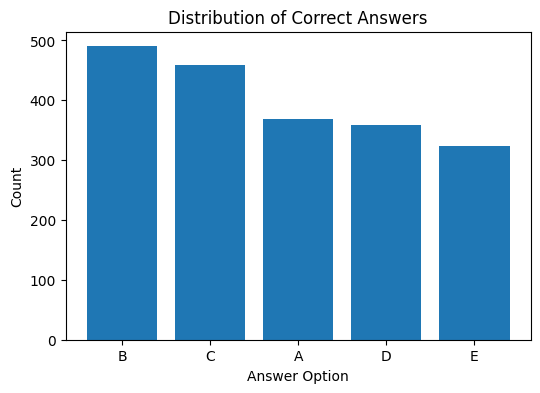

In [9]:
plt.figure(figsize=(6,4))
plt.bar(answer_counts.index, answer_counts.values)

plt.title("Distribution of Correct Answers")
plt.xlabel("Answer Option")
plt.ylabel("Count")

plt.show()

The distribution of the correct answer labels reveals that the dataset is reasonably balanced, although the classes are not perfectly equal. Option B is the most frequent correct answer with 490 occurrences, followed by C (459), A (369), D (358), and E (324). While the class frequencies vary slightly, the imbalance is not severe enough to significantly affect model training.

**Prompt Length Analysis**

In [10]:
train["Prompt Length"] = train["prompt"].str.len()

train["Prompt Length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: Prompt Length, dtype: float64

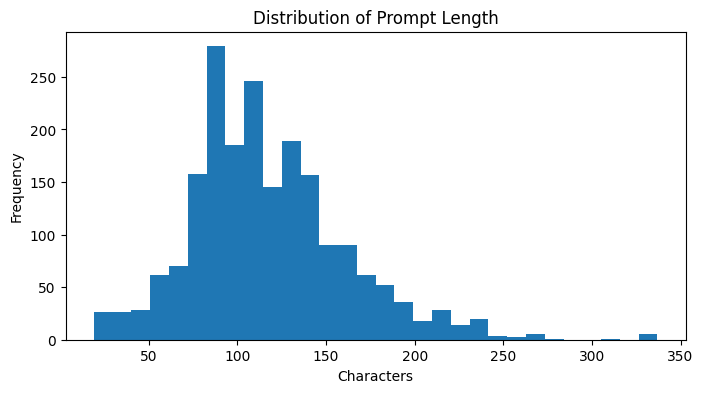

In [11]:
plt.figure(figsize=(8,4))

plt.hist(train["Prompt Length"], bins=30)

plt.title("Distribution of Prompt Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

The prompt length analysis measures the number of characters present in each question prompt. The dataset contains 2,000 prompts, with an average length of approximately 118 characters. The shortest prompt contains 19 characters, while the longest consists of 337 characters, indicating considerable variation in question complexity and detail. Half of the prompts contain 111 characters or fewer, while 75% of the prompts have a length of 141 characters or less.

**Prompt Word Count Analysis**

In [12]:
train["Prompt Word Count"] = train["prompt"].str.split().apply(len)

train["Prompt Word Count"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: Prompt Word Count, dtype: float64

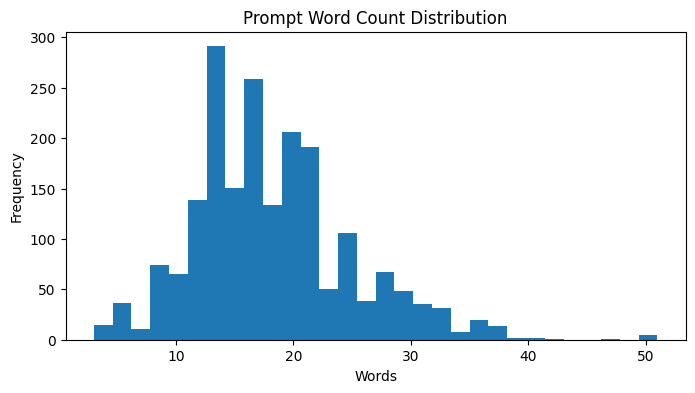

In [13]:
plt.figure(figsize=(8,4))

plt.hist(train["Prompt Word Count"], bins=30)

plt.title("Prompt Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

The prompt word count analysis examines the number of words contained in each question prompt. On average, each prompt consists of approximately 18 words, with the shortest prompt containing only 3 words and the longest containing 51 words. The median prompt length is 17 words, indicating that most questions are relatively concise while still providing sufficient contextual information.

**Option Length Analysis**

In [14]:
for option in ["A","B","C","D","E"]:
    train[f"{option}_Length"] = train[option].str.split().apply(len)

train[[f"{c}_Length" for c in ["A","B","C","D","E"]]].describe()

,A_Length,B_Length,C_Length,D_Length,E_Length
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,26.146000,26.516000,26.54950,25.999500,26.187000
std,17.249651,18.653893,17.20987,17.098909,17.852658
min,1.000000,1.000000,1.00000,1.000000,1.000000
25%,13.000000,12.000000,14.75000,15.000000,13.000000
50%,22.000000,23.000000,24.00000,22.000000,23.000000
75%,37.000000,36.000000,36.00000,36.000000,36.000000
max,81.000000,118.000000,82.00000,78.000000,105.000000


**Average option lengths**

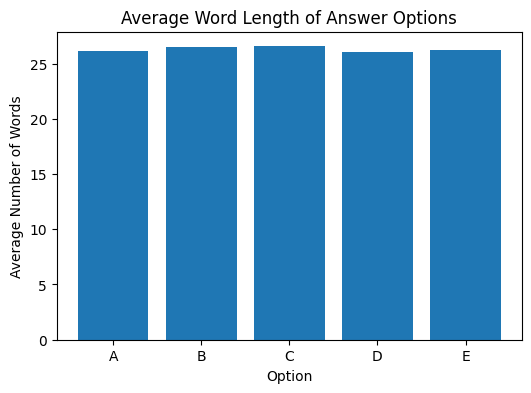

In [15]:
avg_lengths = []

for option in ["A","B","C","D","E"]:
    avg_lengths.append(train[f"{option}_Length"].mean())

plt.figure(figsize=(6,4))

plt.bar(["A","B","C","D","E"], avg_lengths)

plt.title("Average Word Length of Answer Options")

plt.xlabel("Option")

plt.ylabel("Average Number of Words")

plt.show()

The answer option length analysis evaluates the number of words present in each of the five answer choices (A–E). The results show that all five options have a similar average length of approximately 26 words, indicating that the dataset has been designed with fairly balanced answer choices.

# Dummy Submission

In [16]:
import pandas as pd

sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

sample["Prediction"] = "A B C"

sample.to_csv("submission.csv", index=False)

sample.head()

,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


In [17]:
unique_options = pd.DataFrame({
    "Option": ["A", "B", "C", "D", "E"],
    "Unique Answer Choices": [train[col].nunique() for col in ["A", "B", "C", "D", "E"]]
})

unique_options

,Option,Unique Answer Choices
0,A,316
1,B,328
2,C,303
3,D,318
4,E,320


# Model 1 

# Baseline Model: TF-IDF + Cosine Similarity

In [18]:
# Important Libraries

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
# Cleaning Data
import string
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [20]:
train_clean = train.copy()
test_clean = test.copy()

# Clean prompt
train_clean["prompt"] = train_clean["prompt"].apply(clean_text)
test_clean["prompt"] = test_clean["prompt"].apply(clean_text)

# Clean options
for option in ["A", "B", "C", "D", "E"]:
    train_clean[option] = train_clean[option].apply(clean_text)
    test_clean[option] = test_clean[option].apply(clean_text)

In [21]:
# Create combined Corpus
combined_text = (
    train_clean["prompt"] + " " +
    train_clean["A"] + " " +
    train_clean["B"] + " " +
    train_clean["C"] + " " +
    train_clean["D"] + " " +
    train_clean["E"]
)

In [22]:
# Fir TF IDF 

vectorizer = TfidfVectorizer(stop_words="english")

vectorizer.fit(combined_text)

TfidfVectorizer(stop_words='english')

In [23]:
# Creating MAP@3 Function

# Function to calculate Average Precision at K (AP@K) for a single prediction
def apk(actual, predicted, k=3):

    if len(predicted) > k:                   # Keep only the top-k predictions
        predicted = predicted[:k]            

    for i, p in enumerate(predicted):        # Iterate through the predicted labels
        if p == actual:                      # If the correct answer is found, return the score
            return 1 / (i + 1)

    return 0                                 # Return 0 if the correct answer is not in the top-k predictions


# Function to calculate Mean Average Precision at K (MAP@K)
def mapk(actuals, predictions, k=3):
    
    # Compute the average AP@K score over the entire dataset
    return sum(apk(a, p, k) for a, p in zip(actuals, predictions)) / len(actuals)

In [24]:
# Generate Top-3 Predictions using TF-IDF Cosine Similarity

# Store the top-3 predictions for every question
predictions = []

for _, row in train_clean.iterrows():                             # Iterate through every question in the training dataset

    prompt_vec = vectorizer.transform([row["prompt"]])            # Convert the question prompt into a TF-IDF vector

    similarities = []                                             # Store cosine similarity scores for all answer options

    for option in ["A", "B", "C", "D", "E"]:                      # Compare the prompt with each of the five answer options

        option_vec = vectorizer.transform([row[option]])          # Convert the current answer option into a TF-IDF vector

        sim = cosine_similarity(prompt_vec, option_vec)[0][0]     # Calculate cosine similarity between the prompt and the answer option

        similarities.append((option, sim))                        # Save the option label together with its similarity score

    similarities.sort(key=lambda x: x[1], reverse=True)           # Sort answer options in descending order of cosine similarity

    top3 = [x[0] for x in similarities[:3]]                       # Select the three most similar answer options

    predictions.append(top3)                                      # Store the top-3 predictions for the current question

In [25]:
# Evalutaion

score = mapk(train["answer"], predictions)

print(f"TF-IDF Baseline MAP@3 : {score:.4f}")

TF-IDF Baseline MAP@3 : 0.2826


**Prediction on Test Data**

In [26]:

# Generate Top-3 Predictions for the Test Dataset

test_predictions = []

# Iterate through every question in the test dataset
for _, row in test_clean.iterrows():

    # Convert the question prompt into a TF-IDF vector
    prompt_vec = vectorizer.transform([row["prompt"]])

    similarities = []

    # Calculate cosine similarity between the prompt and each answer option
    for option in ["A", "B", "C", "D", "E"]:

        option_vec = vectorizer.transform([row[option]])

        sim = cosine_similarity(prompt_vec, option_vec)[0][0]

        similarities.append((option, sim))

    # Sort options by similarity score (highest first)
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Select the top 3 predicted answer labels
    top3 = [x[0] for x in similarities[:3]]

    test_predictions.append(top3)

In [27]:
# Create Submission File

submission = pd.DataFrame({
    "id": test["id"],
    "prediction": [" ".join(pred) for pred in test_predictions]
})

submission.head()

,id,prediction
0,1,A B C
1,2,A B C
2,3,A D C
3,4,A E C
4,5,A E C


In [28]:
# Save submission file
submission.to_csv("submission.csv", index=False)

In this baseline implementation, exploratory data analysis and text preprocessing were performed to better understand the dataset and prepare it for modeling. A classical Natural Language Processing approach using TF-IDF vectorization and cosine similarity was implemented to rank the five answer options for each multiple-choice question. The model was evaluated using the Mean Average Precision at 3 (MAP@3) metric, achieving a training MAP@3 score of 0.2962 and a Kaggle public leaderboard score of 0.30922. Although the TF-IDF baseline provides a simple and computationally efficient solution, it relies primarily on lexical similarity and does not capture contextual meaning or semantic relationships between the question prompt and answer options.

# Model 2

# Sentence Transformer (MiniLM)

Sentence Transformers generate dense semantic embeddings that capture the contextual meaning of entire sentences. Unlike TF-IDF, which relies on exact word overlap, Sentence Transformers understand semantic relationships between texts, making them more suitable for ranking multiple-choice answers based on meaning.

In [29]:
# Loading the libraries
from sentence_transformers import SentenceTransformer, util

In [30]:
# Load pretrained MiniLM Sentence Transformer
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [31]:
# Generate Predictions

# Store Top-3 predictions
minilm_predictions = []

# Iterate through every question
for _, row in train.iterrows():

    # Encode prompt
    prompt_embedding = model.encode(
        row["prompt"],
        convert_to_tensor=True
    )

    similarities = []

    # Compare prompt with each option
    for option in ["A", "B", "C", "D", "E"]:

        option_embedding = model.encode(
            row[option],
            convert_to_tensor=True
        )

        similarity = util.cos_sim(
            prompt_embedding,
            option_embedding
        ).item()

        similarities.append((option, similarity))

    # Rank options
    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3_minlm_predictions = [x[0] for x in similarities[:3]]

    minilm_predictions.append(top3_minlm_predictions)

In [32]:
#Evaluation
minilm_score = mapk(
    train["answer"],
    minilm_predictions
)

print(f"MiniLM MAP@3 : {minilm_score:.4f}")

MiniLM MAP@3 : 0.4231


In [33]:
minilm_test_predictions = []

for _, row in test.iterrows():

    prompt_embedding = model.encode(
        row["prompt"],
        convert_to_tensor=True
    )

    similarities = []

    for option in ["A","B","C","D","E"]:

        option_embedding = model.encode(
            row[option],
            convert_to_tensor=True
        )

        similarity = util.cos_sim(
            prompt_embedding,
            option_embedding
        ).item()

        similarities.append((option, similarity))

    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3_test_minilm_predictions = [x[0] for x in similarities[:3]]

    minilm_test_predictions.append(" ".join(top3_test_minilm_predictions))

In [34]:
submission = sample.copy()

submission["Prediction"] = minilm_test_predictions

submission.to_csv("submission.csv", index=False)

submission.head()

,ID,Prediction
0,1,B E A
1,2,B D C
2,3,A C D
3,4,A E C
4,5,B C D


# Miscellaneous

****MileStone 1****

Q1,Calculate the frequency distribution of the correct  answer  (A, B, C, D, E) in train.csv. Based on your counts, what is the sum of the occurrences of the most frequent option and the least frequent option? 

In [35]:
import pandas as pd

# Load the training dataset
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")

# Calculate the frequency of each correct answer
answer_counts = train["answer"].value_counts().sort_index()

print("Frequency Distribution:")
print(answer_counts)

# Find the most and least frequent counts
most_frequent = answer_counts.max()
least_frequent = answer_counts.min()

# Calculate their sum
result = most_frequent + least_frequent

print("\nMost Frequent Count :", most_frequent)
print("Least Frequent Count:", least_frequent)
print("Sum =", result)

Frequency Distribution:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

Most Frequent Count : 490
Least Frequent Count: 324
Sum = 814


Q2, After converting the prompt column to lowercase and removing all standard punctuation characters (using Python's string.punctuation), split the text by whitespace. What is the total number of unique words (vocabulary size) across the entire cleaned prompt column of train.csv?  

In [36]:
import string


# Create a translation table to remove punctuation
translator = str.maketrans("", "", string.punctuation)

# Clean the prompt column:
# 1. Convert to lowercase
# 2. Remove punctuation
# 3. Split into words
cleaned_words = (
    train["prompt"]
    .astype(str)
    .str.lower()
    .str.translate(translator)
    .str.split()
)

# Build the vocabulary (unique words)
vocabulary = set()

for words in cleaned_words:
    vocabulary.update(words)

# Vocabulary size
print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 859


Q3, Using the cleaned prompt from Row ID 1, filter out the standard English stop words using sklearn.feature_extraction.text.ENGLISH_STOP_WORDS. How many words are left in the prompt for Row ID 1 after filtering?

In [37]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Select Row ID = 1
prompt = train.loc[train["id"] == 1, "prompt"].iloc[0]

# Clean the text
cleaned = prompt.lower().translate(translator)

# Split into words
words = cleaned.split()

# Remove English stop words
filtered_words = [word for word in words if word not in ENGLISH_STOP_WORDS]

# Print results
print("Original Prompt:")
print(prompt)

print("\nWords after removing stop words:")
print(filtered_words)

print("\nNumber of words left:", len(filtered_words))

Original Prompt:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

Words after removing stop words:
['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']

Number of words left: 13


Q4, Fit a default TfidfVectorizer(stop_words='english') on a list containing all the combined text of the prompts and options in train.csv. What is the exact total number of feature columns (vocabulary size) generated by the vectorizer?

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine prompt and all answer options into one text per row
combined_text = (
    train["prompt"].fillna("") + " " +
    train["A"].fillna("") + " " +
    train["B"].fillna("") + " " +
    train["C"].fillna("") + " " +
    train["D"].fillna("") + " " +
    train["E"].fillna("")
)

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Fit the vectorizer
X = vectorizer.fit_transform(combined_text)

# Vocabulary size (number of feature columns)
print("Total feature columns:", len(vectorizer.get_feature_names_out()))

# Alternative (same answer)
print("Shape:", X.shape)
print("Number of features:", X.shape[1])

Total feature columns: 2762
Shape: (2000, 2762)
Number of features: 2762


Q5, Using the TF-IDF vectorizer fitted in Question 3, calculate the cosine similarity between the prompt and option A strictly for Row ID 1. What is the resulting similarity score? (Round to 4 decimal places).

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

# Select Row ID = 1
row = train.loc[train["id"] == 1].iloc[0]

# Transform the prompt and Option A using the already fitted vectorizer
prompt_vec = vectorizer.transform([row["prompt"]])
option_a_vec = vectorizer.transform([row["A"]])

# Calculate cosine similarity
similarity = cosine_similarity(prompt_vec, option_a_vec)[0][0]

print("Cosine Similarity:", round(similarity, 4))

Cosine Similarity: 0.272


Q6, Expand the logic from Question 4: For every row in train.csv, calculate the cosine similarity between the prompt and each of its 5 options .  Then calculate the percentage of instances where the option with the highest cosine similarity matches the correct answer. 

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

correct_predictions = 0

# Loop through every row
for _, row in train.iterrows():

    # TF-IDF vector of the prompt
    prompt_vec = vectorizer.transform([row["prompt"]])

    similarities = []

    # Calculate similarity with each option
    for option in ["A", "B", "C", "D", "E"]:
        option_vec = vectorizer.transform([row[option]])
        sim = cosine_similarity(prompt_vec, option_vec)[0][0]
        similarities.append(sim)

    # Find the option with the highest similarity
    predicted_option = ["A", "B", "C", "D", "E"][similarities.index(max(similarities))]

    # Compare with the actual answer
    if predicted_option == row["answer"]:
        correct_predictions += 1

# Calculate percentage accuracy
percentage = (correct_predictions / len(train)) * 100

print(f"Correct Predictions : {correct_predictions}")
print(f"Total Questions     : {len(train)}")
print(f"Percentage          : {percentage:.2f}%")

Correct Predictions : 271
Total Questions     : 2000
Percentage          : 13.55%


Q7, If the ground truth answer for a question is C, what is the MAP@3 score if a model predicts C A B?

1.0

Q8, If the ground truth answer for a question is  B, what is the MAP@3 score if a model predicts D B E? 

0.5

Q9, The Majority Class Baseline: Find the most frequent correct answer in the training set (using your data from Q1). Make a static prediction for every single row where that most frequent answer is your 1st guess, followed by the second most frequent, and then the third most frequent. What is the overall MAP@3 score of this "Majority Class" baseline on train.csv?

In [41]:
# Top 3 most frequent answer labels
top3 = answer_counts.index[:3].tolist()

print("Top 3 Majority Classes:", top3)

# Calculate MAP@3
map3_score = 0

for actual in train["answer"]:
    if actual == top3[0]:
        map3_score += 1.0
    elif actual == top3[1]:
        map3_score += 0.5
    elif actual == top3[2]:
        map3_score += 1/3
    else:
        map3_score += 0

map3_score /= len(train)

print(f"Majority Class Baseline MAP@3: {map3_score:.4f}")

Top 3 Majority Classes: ['A', 'B', 'C']
Majority Class Baseline MAP@3: 0.3835


Q10, The TF-IDF Pipeline: Build a basic pipeline that evaluates every row in train.csv. For each row, calculate the TF-IDF cosine similarity between the prompt and each of the 5 options. Sort these options from highest similarity to lowest to form your top 3 predictions. What is the final average MAP@3 score of this TF-IDF pipeline across the entire training set?

In [42]:
from sklearn.metrics.pairwise import cosine_similarity

map3_score = 0

# Loop through each question
for _, row in train.iterrows():

    # TF-IDF vector of the prompt
    prompt_vec = vectorizer.transform([row["prompt"]])

    similarities = []

    # Compute similarity with each option
    for option in ["A", "B", "C", "D", "E"]:
        option_vec = vectorizer.transform([row[option]])
        sim = cosine_similarity(prompt_vec, option_vec)[0][0]
        similarities.append((option, sim))

    # Sort options by similarity (highest first)
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Top 3 predicted options
    top3_predictions = [x[0] for x in similarities[:3]]

    # Ground truth
    actual = row["answer"]

    # Calculate AP@3 for this row
    if actual in top3_predictions:
        rank = top3_predictions.index(actual) + 1
        map3_score += 1 / rank

# Final MAP@3
map3_score /= len(train)

print(f"TF-IDF Pipeline MAP@3: {map3_score:.4f}")

TF-IDF Pipeline MAP@3: 0.2962


**Milestone 2**

Q1, Introduction to Hugging Face transformers and datasets
Load train.csv using the Hugging Face datasets library (do not use pandas). Use the .map() function to create a new column called combined_text that concatenates the prompt and A columns with a space in between. E.g., prompt_text A_text. What is the exact character length (total number of string characters using Python's len() function, NOT the number of tokens) of the combined_text string for the row at index 51? Note: We follow zero-indexing here.

In [43]:
#Installing the dataset library

!pip install datasets -q

In [44]:
# Importing the library
from datasets import load_dataset

#Loading the training dataset
dataset = load_dataset("csv", data_files="/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")

train_ds = dataset["train"]

Generating train split: 0 examples [00:00, ? examples/s]

In [45]:
#Create the combined_text column using .map()

def combine_prompt_option(example):
    example["combined_text"] = example["prompt"] + " " + example["A"]
    return example

train_ds = train_ds.map(combine_prompt_option)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [46]:
#Find the character length of row 51

length = len(train_ds[51]["combined_text"])

print("Character Length:", length)

Character Length: 614


Q2, Initialize the bert-base-uncased tokenizer. Look at the tokenizer's configuration properties: what is the exact total vocabulary size (the maximum number of unique subword tokens the model knows) hardcoded into this tokenizer? 

In [47]:
# Install Transformers
!pip install transformers -q

In [48]:
# Importing Autotokenizer
from transformers import AutoTokenizer

#Loading the BERT Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [49]:
print("Vocabulary Size:", tokenizer.vocab_size)

Vocabulary Size: 30522


Q3, Transformers rely on special tokens to understand sentence boundaries. Using the bert-base-uncased tokenizer from the previous step, extract the exact integer ID assigned to the [SEP] (Separator) token.  

In [50]:
# Get the token ID of the [SEP] token
sep_token_id = tokenizer.sep_token_id

print("SEP Token ID:", sep_token_id)

SEP Token ID: 102


Q4, Using the bert-base-uncased tokenizer, tokenize the entire prompt column of the train dataset simultaneously. Set padding='max_length', truncation=True, max_length=128, and return_tensors='pt' (PyTorch tensors). 

What is the exact geometric shape (dimensions) of the resulting input_ids tensor?

In [51]:
#Converting the column to a Python list before tokenizing
prompts = train_ds["prompt"]

# Tokenize the entire prompt column
encoded = tokenizer(
    list(prompts),
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Display the shape of the input_ids tensor
print("Input IDs Shape:", encoded["input_ids"].shape)

Input IDs Shape: torch.Size([2000, 128])


Q5, BERT/RoBERTa Architecture & Attention Mechanisms
A standard bert-base-uncased model has a hidden embedding size of 768 dimensions and uses exactly 12 attention heads in each layer. 

In Transformer architecture, the hidden size is divided equally among the attention heads. What is the exact dimensionality (size) of each individual attention head? 

In [52]:
hidden_size = 768
num_attention_heads = 12

head_dimension = hidden_size // num_attention_heads

print("Dimension of each attention head:", head_dimension)

Dimension of each attention head: 64


Q6, Load the bert-base-uncased model using AutoModel.from_pretrained(). Tokenize the prompt from row ID 0 using the tokenizer's default settings (do not apply any manual padding or truncation). Pass this tokenized input through the model. Look at the output object. 

What is the exact shape of the last_hidden_state tensor returned? 

Note: We follow zero-indexing here.

In [53]:
from transformers import AutoModel

# Load the BERT model
model = AutoModel.from_pretrained("bert-base-uncased")

#get the prompt from row 0
prompt = train_ds[0]["prompt"]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [54]:
#tokenize
inputs = tokenizer(prompt, return_tensors="pt")

#Passing through bERT
outputs = model(**inputs)

#Chekcing the shape
print(outputs.last_hidden_state.shape)

torch.Size([1, 31, 768])


Q7, Using the last_hidden_state tensor from the previous question, extract the embedding vector representing the [CLS] token (which is always the token at index 0). What is the sum of the first 5 float values in this [CLS] vector? (Round your answer to 4 decimal places). 

In [55]:
# Extract the embedding of the [CLS] token
cls_embedding = outputs.last_hidden_state[0, 0]

# Display the first five values
print("First 5 values:")
print(cls_embedding[:5])

# Calculate the sum of the first five values
answer = cls_embedding[:5].sum().item()

print("Answer:", round(answer, 4))

First 5 values:
tensor([-0.4677, -0.0754, -0.2019, -0.0071, -0.4480], grad_fn=<SliceBackward0>)
Answer: -1.2001


Q8, Load bert-base-uncased with the parameter output_attentions=True. Tokenize the exact string "Light-ion fusion is a technique." (ensuring you set return_tensors='pt') and pass it through the model. Extract the attention matrix for the last layer (index -1) and the first attention head (head index 0). 

What is the exact attention weight (a float value) that the [CLS] token (token index 0) pays to the word fusion (you will need to find the specific token index for fusion in the input_ids)? (Round your answer to 4 decimal places). 

In [56]:
# Load the model with attention output
from transformers import AutoTokenizer, AutoModel

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Load model and enable attention outputs
model = AutoModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
# Tokenize the sentence
sentence = "Light-ion fusion is a technique."

inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

In [58]:
#pass through BERT
outputs = model(**inputs)

#Display the tokens
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

for i, token in enumerate(tokens):
    print(i, token)

0 [CLS]
1 light
2 -
3 ion
4 fusion
5 is
6 a
7 technique
8 .
9 [SEP]


In [59]:
#Finding the index of 'Fusion'
fusion_index = tokens.index("fusion")

print("Fusion Token Index:", fusion_index)

Fusion Token Index: 4


In [60]:
#Extract the Attention Matrix
# Last transformer layer
last_layer_attention = outputs.attentions[-1]

print(last_layer_attention.shape)

torch.Size([1, 12, 10, 10])


In [61]:
# First Attention Head
head0 = last_layer_attention[0, 0]

# Attention from[CLS] to Fusion
attention_weight = head0[0, fusion_index].item()

print("Attention Weight:", round(attention_weight, 4))

Attention Weight: 0.1025


Q9, Context-Aware Embeddings 
Initialize the sentence-transformers/all-MiniLM-L6-v2 model. Use the model's .encode() method to generate embeddings for both the prompt and Option B for row ID 0. Calculate the cosine similarity between these two vectors specifically using the sentence_transformers.util.cos_sim() function. What is the resulting similarity score rounded to 4 decimal places? Note: We follow zero-indexing here.

In [62]:
# Installing the sentence transformer
!pip install sentence-transformers -q

In [63]:
from sentence_transformers import SentenceTransformer, util

#load the model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [64]:
# Extract the prompt and the option B
prompt = train_ds[0]["prompt"]
option_b = train_ds[0]["B"]

In [65]:
# generating the sentence embedding
prompt_embedding = model.encode(prompt, convert_to_tensor=True)

option_b_embedding = model.encode(option_b, convert_to_tensor=True)

In [66]:
# Computing the cosine similarity
similarity = util.cos_sim(
    prompt_embedding,
    option_b_embedding
)

print("Cosine Similarity:", round(similarity.item(), 4))

Cosine Similarity: 0.7658


Q10, Build two complete ranking pipelines evaluating every row in train.csv.

Pipeline 1: Use the TF-IDF cosine similarity approach from Milestone 1.

Pipeline 2: Use the sentence-transformers/all-MiniLM-L6-v2 model to generate embeddings for the prompt and all five options. Rank options using cosine similarity to form Top-3 predictions.

First, what is the final MAP@3 score of the all-MiniLM-L6-v2 pipeline across the entire training set? 

Second, count the number of questions for which the correct answer is NOT present in the TF-IDF Top-3 predictions BUT IS present in the MiniLM Top-3 predictions. What is this exact resulting count?  

In [67]:
# Load the sentence Transformer
from sentence_transformers import SentenceTransformer, util

# Load the MiniLM model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [68]:
# MiniLM Ranking Pipeline


minilm_predictions = []

for row in train_ds:

    # Encode the question prompt
    prompt_embedding = model.encode(
        row["prompt"],
        convert_to_tensor=True
    )

    similarities = []

    # Compare with each answer option
    for option in ["A", "B", "C", "D", "E"]:

        option_embedding = model.encode(
            row[option],
            convert_to_tensor=True
        )

        similarity = util.cos_sim(
            prompt_embedding,
            option_embedding
        ).item()

        similarities.append((option, similarity))

    # Rank by cosine similarity
    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [x[0] for x in similarities[:3]]

    minilm_predictions.append(top3)

In [69]:
# Calculate MAP@# Score
minilm_score = mapk(
    train_ds["answer"],
    minilm_predictions
)

print("MiniLM MAP@3:", round(minilm_score, 4))

MiniLM MAP@3: 0.4231


In [70]:
# Improvement Count
improved_count = 0

for i in range(len(train_ds)):

    actual = train_ds[i]["answer"]

    tfidf_correct = actual in predictions[i]

    minilm_correct = actual in minilm_predictions[i]

    if (not tfidf_correct) and minilm_correct:
        improved_count += 1

print(improved_count)

494


Q11,Zero-shot classification concepts 
Initialize the Hugging Face pipeline for "zero-shot-classification" (it will default to facebook/bart-large-mnli). For the prompt of the 2nd row (index 1), pass Options A, B, and C as the candidate_labels. What is the probability score given to the top-ranked option? (Round to 4 decimal places).

In [71]:
#import pipeline
from transformers import pipeline

# Initialize zero shot pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [72]:
#Extract Prompt and  Candidiate lables
sequence = train_ds[1]["prompt"]

candidate_labels = [
    train_ds[1]["A"],
    train_ds[1]["B"],
    train_ds[1]["C"]
]

In [73]:
#Perform zero shot Classification
result = classifier(
    sequence,
    candidate_labels
)

print(result)

top_score = result["scores"][0]

print("Top Probability:", round(top_score, 4))

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion

Q12, Run the exact same zero-shot classification as the previous question, but this time pass the argument multi_label=True. 

What is the absolute difference between the sum of the 3 probabilities in the previous question (which uses Softmax) and the sum of the 3 probabilities in this question (which uses independent Sigmoids)?

In [74]:
# Run the classifer with multilabel = true

result_multilabel = classifier(
    sequence,
    candidate_labels,
    multi_label=True
)

print(result_multilabel)

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion 

In [75]:
# Calculating the sums

# Sum of probabilities from Softmax (Q11)
softmax_sum = sum(result["scores"])

# Sum of probabilities from Independent Sigmoids (Q12)
sigmoid_sum = sum(result_multilabel["scores"])

print("Softmax Sum :", softmax_sum)
print("Sigmoid Sum :", sigmoid_sum)

Softmax Sum : 0.9999999701976776
Sigmoid Sum : 0.0005096072964079212


In [76]:
# Absolute Difference
difference = abs(softmax_sum - sigmoid_sum)

print("Absolute Difference:", round(difference, 4))

Absolute Difference: 0.9995


Q13, Let's try Generative AI instead of Classification. 

Load a Small Language Model like google/flan-t5-small using the Hugging Face pipeline("text2text-generation"). Construct the following exact string for row index 0: "Question: [prompt]. Is the correct answer A: [A] or B: [B]? Answer with just the letter A or B." 
Pass this string to the pipeline, setting max_new_tokens=5. What is the exact string output returned by the model? 

In [77]:
#Load FLAN-T5 Small

#generator = pipeline("text2text-generation",model="google/flan-t5-small")

In [78]:
#import transformers
#print(transformers.__version__)

In [79]:
# Constructing the prompt
'''prompt = (
    f"Question: {train_ds[0]['prompt']}. "
    f"Is the correct answer A: {train_ds[0]['A']} "
    f"or B: {train_ds[0]['B']}? "
    f"Answer with just the letter A or B."
)'''

'prompt = (\n    f"Question: {train_ds[0][\'prompt\']}. "\n    f"Is the correct answer A: {train_ds[0][\'A\']} "\n    f"or B: {train_ds[0][\'B\']}? "\n    f"Answer with just the letter A or B."\n)'

In [80]:
# Generate Response
'''result = generator(
    prompt,
    max_new_tokens=5
)

print(result)'''

'result = generator(\n    prompt,\n    max_new_tokens=5\n)\n\nprint(result)'

In [81]:
# Generate only the text
#answer = result[0]["generated_text"]

#print("Model Output:", answer)